In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

# Use current working directory (run notebook from the folder that contains runtime.csv, etc.)
base_path = Path(".").resolve()

# ── Shared style settings ──
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.color": "#cccccc",
    "grid.linestyle": "--",
    "grid.alpha": 0.6,
    "font.family": "serif",
    "font.size": 12,
})

CPLEX_COLOR = "#E8860C"   # orange
GA_COLOR    = "#228B22"   # forest green


def plot_bar_from_csv(csv_name: str, y_label: str):
    """Publication-quality grouped bar chart (Optimum vs Genetic algorithm)."""
    df = pd.read_csv(base_path / csv_name)
    nodes = df["node"].astype(str)
    cplex_vals = df["CPLEX"].values
    ga_vals    = df["GA"].values

    x = np.arange(len(nodes))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))

    bars1 = ax.bar(
        x - width / 2, cplex_vals, width,
        label="Optimum", color=CPLEX_COLOR,
        edgecolor="black", linewidth=0.8,
        hatch="...",
    )
    bars2 = ax.bar(
        x + width / 2, ga_vals, width,
        label="Genetic algorithm", color=GA_COLOR,
        edgecolor="black", linewidth=0.8,
        hatch="///",
    )

    # Value labels on top of each bar
    for bar_group in (bars1, bars2):
        for bar in bar_group:
            h = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2, h + 0.5,
                f"{h:g}", ha="center", va="bottom",
                fontsize=10, fontweight="bold",
            )

    ax.set_xlabel("Number of Nodes", fontsize=13, fontweight="bold")
    ax.set_ylabel(y_label, fontsize=13, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(nodes, fontsize=12)
    ax.legend(title="Algorithm", fontsize=11, title_fontsize=11,
              frameon=True, fancybox=True, shadow=True)
    ax.set_axisbelow(True)

    # Give a little headroom for the value labels
    ymin = min(min(cplex_vals), min(ga_vals))
    ymax = max(max(cplex_vals), max(ga_vals))
    margin = (ymax - ymin) * 0.15
    ax.set_ylim(bottom=max(0, ymin - margin * 2), top=ymax + margin)

    plt.tight_layout()
    plt.show()


def plot_runtime_line(csv_name: str = "runtime.csv"):
    """Line chart for runtime comparison (Optimum vs Genetic algorithm)."""
    df = pd.read_csv(base_path / csv_name)
    nodes = df["node"].values
    cplex_vals = df["CPLEX"].values / 1000  # Scale to x10^3 sec
    ga_vals    = df["GA"].values / 1000     # Scale to x10^3 sec

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(
        nodes, cplex_vals,
        color="#7B2D8E", marker="o", markersize=8,
        linestyle="--", linewidth=2,
        label="Optimum",
    )
    ax.plot(
        nodes, ga_vals,
        color=GA_COLOR, marker="v", markersize=8,
        linestyle="-", linewidth=2,
        label="Genetic algorithm",
    )

    # Add annotation for 24 nodes if it exists in the data
    if 24 in nodes:
        idx_24 = np.where(nodes == 24)[0][0]
        cplex_24_val = cplex_vals[idx_24]
        ax.annotate(
            f"No Result ({cplex_24_val:.1f}x10\u00b3 sec)",
            xy=(24, cplex_24_val),
            xytext=(0.55, 0.88),
            textcoords='axes fraction',
            xycoords='data',
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5,
                            connectionstyle='arc3,rad=0.0'),
            fontsize=10,
            fontweight="bold",
            ha='center',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                      edgecolor='black', alpha=0.9)
        )

    ax.set_xlabel("Number of Nodes", fontsize=13, fontweight="bold")
    ax.set_ylabel("Execution Time (x10^3 sec)", fontsize=13, fontweight="bold")
    ax.set_xticks(nodes)
    ax.legend(title="Algorithm", fontsize=11, title_fontsize=11,
              frameon=True, fancybox=True, shadow=True)
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.show()

## Runtime

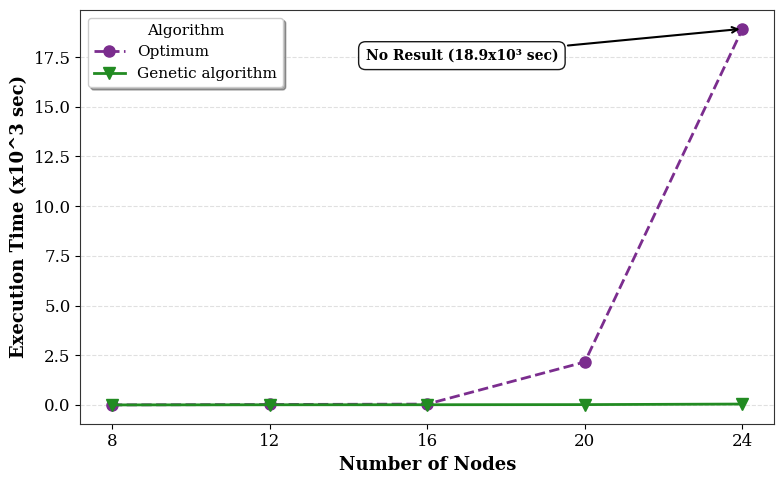

In [4]:
plot_runtime_line("runtime.csv")

## Distance

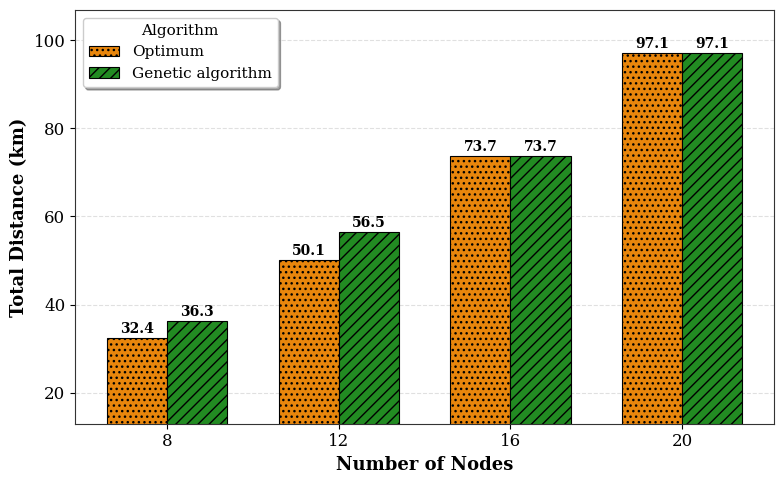

In [5]:
plot_bar_from_csv("distance.csv", "Total Distance (km)")

## Travel Time

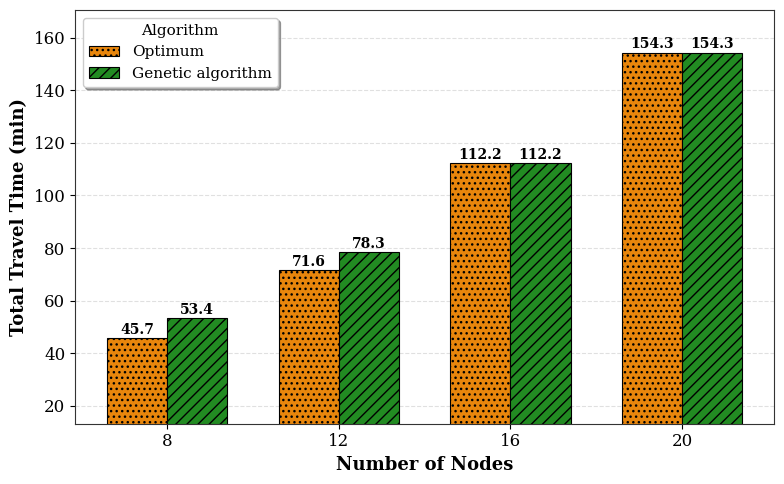

In [6]:
plot_bar_from_csv("travelTime.csv", "Total Travel Time (min)")

## Energy Consumption

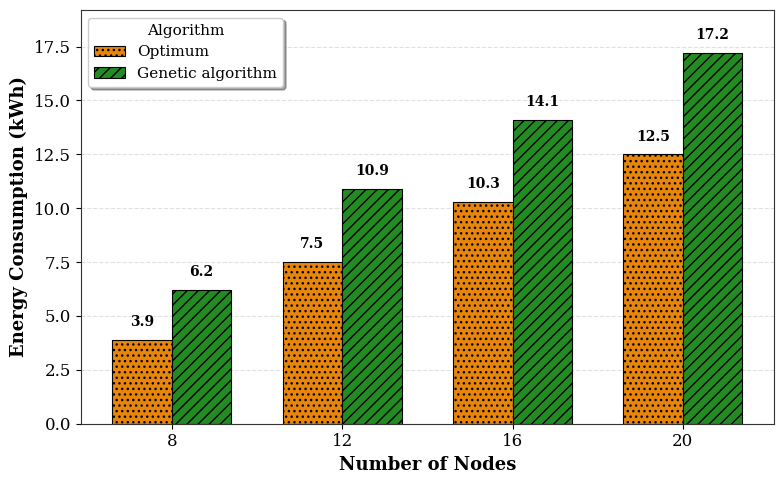

In [7]:
plot_bar_from_csv("energy_consumption.csv", "Energy Consumption (kWh)")

## Energy Charge (CS and ERS)

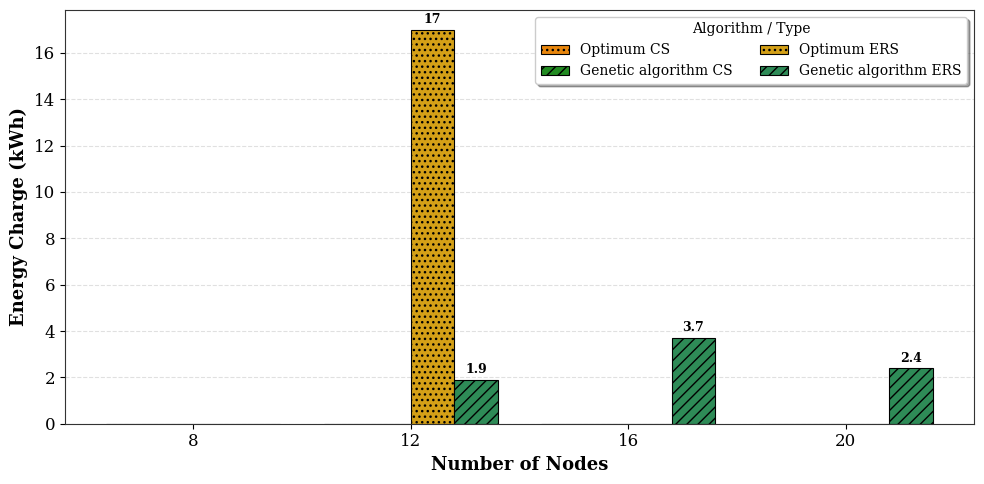

In [8]:
df_cs  = pd.read_csv(base_path / "energy_charge_CS.csv")
df_ers = pd.read_csv(base_path / "energy_charge_ERS.csv")

nodes = df_cs["node"].astype(str).values
x = np.arange(len(nodes))
width = 0.2

vals = {
    "Optimum CS":  df_cs["CPLEX"].values,
    "Genetic algorithm CS":    df_cs["GA"].values,
    "Optimum ERS": df_ers["CPLEX"].values,
    "Genetic algorithm ERS":   df_ers["GA"].values,
}

colors   = [CPLEX_COLOR, GA_COLOR, "#D4A017", "#2E8B57"]
hatches  = ["...", "///", "...", "///"]
offsets  = [-1.5, -0.5, 0.5, 1.5]

fig, ax = plt.subplots(figsize=(10, 5))

for (label, v), color, hatch, off in zip(vals.items(), colors, hatches, offsets):
    bars = ax.bar(
        x + off * width, v, width,
        label=label, color=color,
        edgecolor="black", linewidth=0.8, hatch=hatch,
    )
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2, h + 0.15,
                f"{h:g}", ha="center", va="bottom",
                fontsize=9, fontweight="bold",
            )

ax.set_xlabel("Number of Nodes", fontsize=13, fontweight="bold")
ax.set_ylabel("Energy Charge (kWh)", fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(nodes, fontsize=12)
ax.legend(title="Algorithm / Type", fontsize=10, title_fontsize=10,
          frameon=True, fancybox=True, shadow=True, ncol=2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()